# <font color = "red">**Deciphering the Decision Logic of an AI Agent**</font>

- Can we infer what an AI agent values by observing the sequence of decisions it makes?

- In this challenge, GPT acts as an autonomous microscopy agent that repeatedly selects one measurement location from a set of candidate AFM image patches.

- We record its decisions and then attempt to reverse-engineer the hidden logic behind those choices using visual, statistical, and data-driven methods.

<font color = "blue" size = 6>**Goal**</font>: develop a method that best explains GPT’s behavior and predicts its future decisions on unseen candidate sets.

<a href="https://colab.research.google.com/github/kbarakati/camm_hackathon/blob/k4my4r/docs/day_20_10092026/llm_decision_making.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports and reproducibility

In [ ]:
! pip install -q igor2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from igor2 import binarywave
import pickle

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

import random
np.random.seed(42)


Download data

In [2]:
# ! gdown --folder "https://drive.google.com/drive/folders/1Gy7PeI4EhmlNE5hLxvP9p9A4u026QQ_X?usp=sharing"

## load data

In [3]:
fname = "scan_main_0000.ibw"

ibw = binarywave.load(fname)

wave = ibw["wave"]

data = np.array(
    wave["wData"]
)

img_data = np.moveaxis(data,-1, 0)

channels = [
    "Height",
    "Amplitude1",
    "Amplitude2",
    "Phase1",
    "Phase2",
    "Frequency"
]

print("Channels:", channels)
print("Shape:", img_data.shape)
print("Mode: DART Mode")

Channels: ['Height', 'Amplitude1', 'Amplitude2', 'Phase1', 'Phase2', 'Frequency']
Shape: (6, 256, 256)
Mode: DART Mode


In [ ]:
trace_files = [
    "gpt_decision_trace_0.pkl",
    "gpt_decision_trace_1.pkl",
    "gpt_decision_trace_2.pkl",

    "simulated_decision_trace_0.pkl",
    "simulated_decision_trace_1.pkl",
    "simulated_decision_trace_2.pkl",
    "simulated_decision_trace_3.pkl",
    "simulated_decision_trace_4.pkl",
    "simulated_decision_trace_5.pkl",
    "simulated_decision_trace_6.pkl",
    "simulated_decision_trace_7.pkl",
]


traces = {}

for i, fname in enumerate(trace_files):

    with open(fname, "rb") as f:
        traces[i] = pickle.load(f)

Plot the AFM image

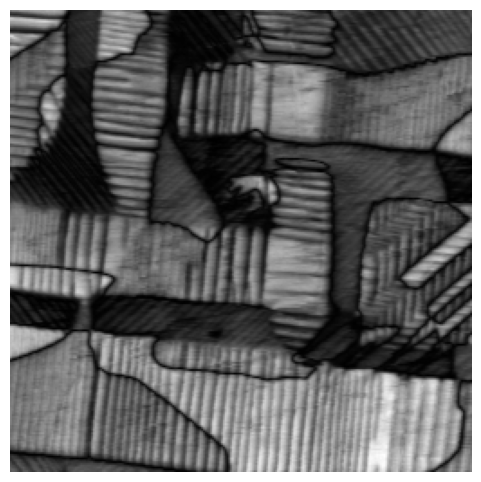

In [23]:
channel_index = 2 #--> we want amplitude

img = img_data[channel_index].T
img = (img - img.min()) / (img.max() - img.min())

plt.figure(figsize=(6, 6))

plt.imshow(
    img,
    cmap="gray"
)

plt.axis("off")
plt.show()

Each trace contains multiple decision steps.

For every step:

- `patches` contains all candidate image patches available to the agent.
- `selected_candidate` gives the candidate selected by the agent.
- `selected_patch` contains the selected image patch.
- `position` gives the selected location in the original AFM image.
- `score` may be available for some traces.

In [24]:
TRACE_ID = 4
STEP = 1

trace = traces[TRACE_ID]

step_data = trace[STEP - 1]

print("Selected candidate:",
      step_data["selected_candidate"])

print("Position:",
      step_data["position"])

print("Number of candidates:",
      len(step_data["patches"]))

if "score" in step_data:
    print("Score:",
          step_data["score"])

Selected candidate: 6
Position: (189, 183)
Number of candidates: 20
Score: 1.0


VISUALIZE ONE DECISION STEP

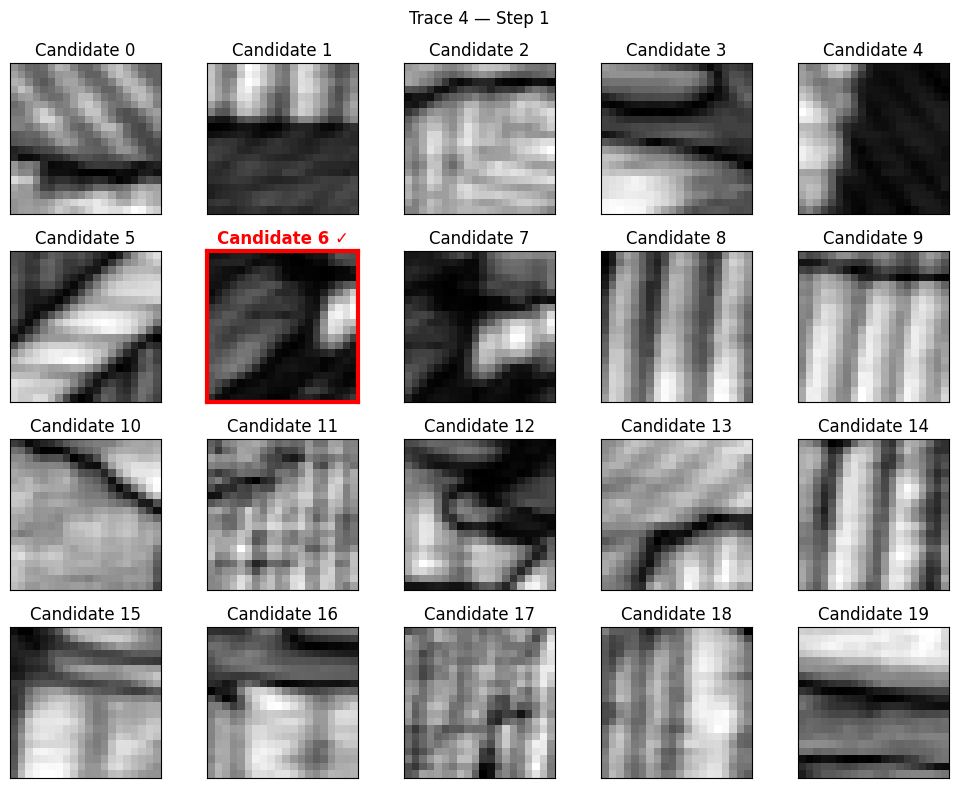

In [25]:
patches = step_data["patches"]
selected = step_data["selected_candidate"]

n = len(patches)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(10, 2 * nrows)
)

axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):

    if i >= n:
        ax.axis("off")
        continue

    ax.imshow(
        patches[i],
        cmap="gray"
    )

    if i == selected:

        ax.set_title(
            f"Candidate {i} ✓",
            color="red",
            weight="bold"
        )

        for spine in ax.spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(3)

    else:

        ax.set_title(
            f"Candidate {i}"
        )

    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    f"Trace {TRACE_ID} — Step {STEP}"
)

plt.tight_layout()
plt.show()

TRACE MAP ON ORIGINAL IMAGE

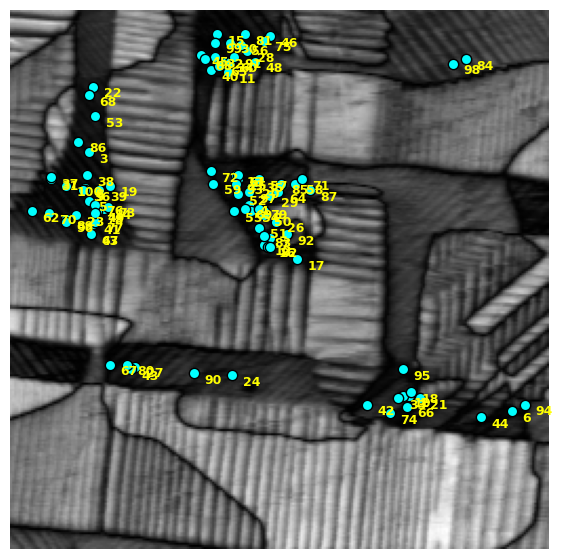

In [26]:
trace = traces[TRACE_ID]

steps = sorted(trace.keys())

xs = [
    trace[step]["position"][0]
    for step in steps
]

ys = [
    trace[step]["position"][1]
    for step in steps
]


fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.imshow(
    img,
    cmap="gray"
)


# ------------------------------------------------------------
# Plot all selected locations
# ------------------------------------------------------------

ax.scatter(
    xs,
    ys,
    s=55,
    color="cyan",
    edgecolors="black"
)


# ------------------------------------------------------------
# Label each point by decision step
# ------------------------------------------------------------

for step, x, y in zip(
    steps,
    xs,
    ys
):

    ax.text(
        x + 5,
        y + 5,
        str(step + 1),
        fontsize=9,
        color="yellow",
        weight="bold"
    )


ax.axis("off")

plt.show()

DECISION MAPS FOR 10 TRACES

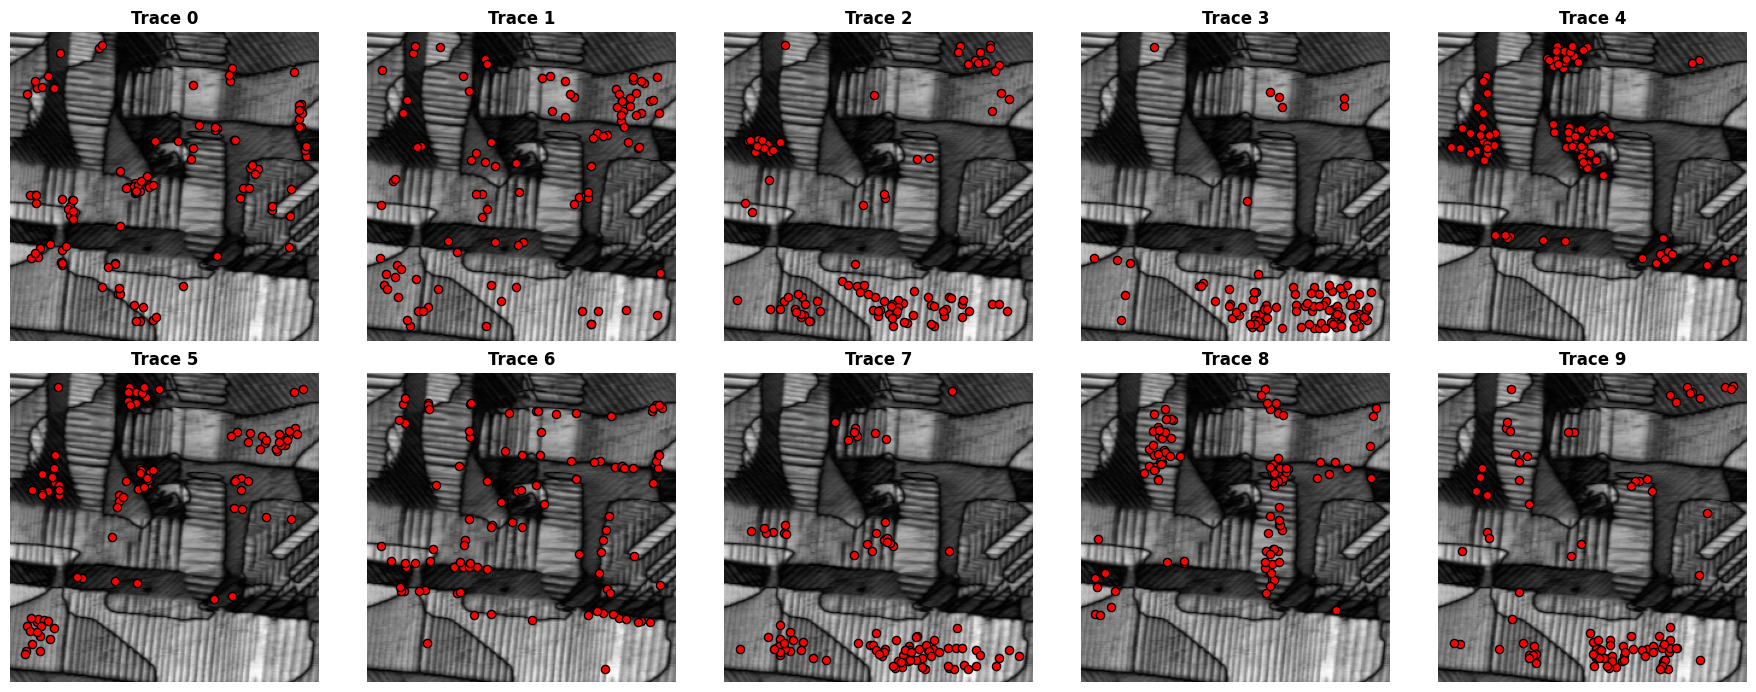

In [27]:
TRACE_IDS = list(traces.keys())[:10]

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 7)
)

axes = axes.flatten()


for ax, trace_id in zip(axes, TRACE_IDS):

    trace = traces[trace_id]

    steps = sorted(trace.keys())

    xs = [
        trace[step]["position"][0]
        for step in steps
    ]

    ys = [
        trace[step]["position"][1]
        for step in steps
    ]


    # Original AFM image
    ax.imshow(
        img,
        cmap="gray"
    )


    # Selected locations
    ax.scatter(
        xs,
        ys,
        s=35,
        color="r",
        edgecolors="black"
    )

    ax.set_title(
        f"Trace {trace_id}",
        fontsize=12,
        weight="bold"
    )

    ax.axis("off")


plt.tight_layout()
plt.show()

# What Makes a Patch Get Selected?

Each decision step contains 20 candidate patches, but only one was selected.
The goal is to discover visual or quantitative characteristics that may explain the hidden objective.

### DEFINE YOUR HYPOTHESIZED REWARD

In [28]:
def reward(patch):

    p = patch.astype(float)

    # --------------------------------------------------------
    # YOUR HYPOTHESIS HERE
    # --------------------------------------------------------

    score = np.mean(p)   # example only — modify this

    return score


### SCORE ALL PATCHES IN ONE STEP

In [29]:
TRACE_ID = 6
STEP = 1

trace = traces[TRACE_ID]
step_data = trace[STEP - 1]

patches = step_data["patches"]
actual_selected = step_data["selected_candidate"]


# Score all 20 candidates
scores = np.array([
    reward(patch)
    for patch in patches
])


# Select highest-scoring candidate
predicted_selected = int(
    np.argmax(scores)
)

print(
    f"Actual selection:    Candidate {actual_selected}"
)

print(
    f"Predicted selection: Candidate {predicted_selected}"
)

Actual selection:    Candidate 16
Predicted selection: Candidate 18



### VISUALIZE PREDICTED vs ACTUAL CLEARLY

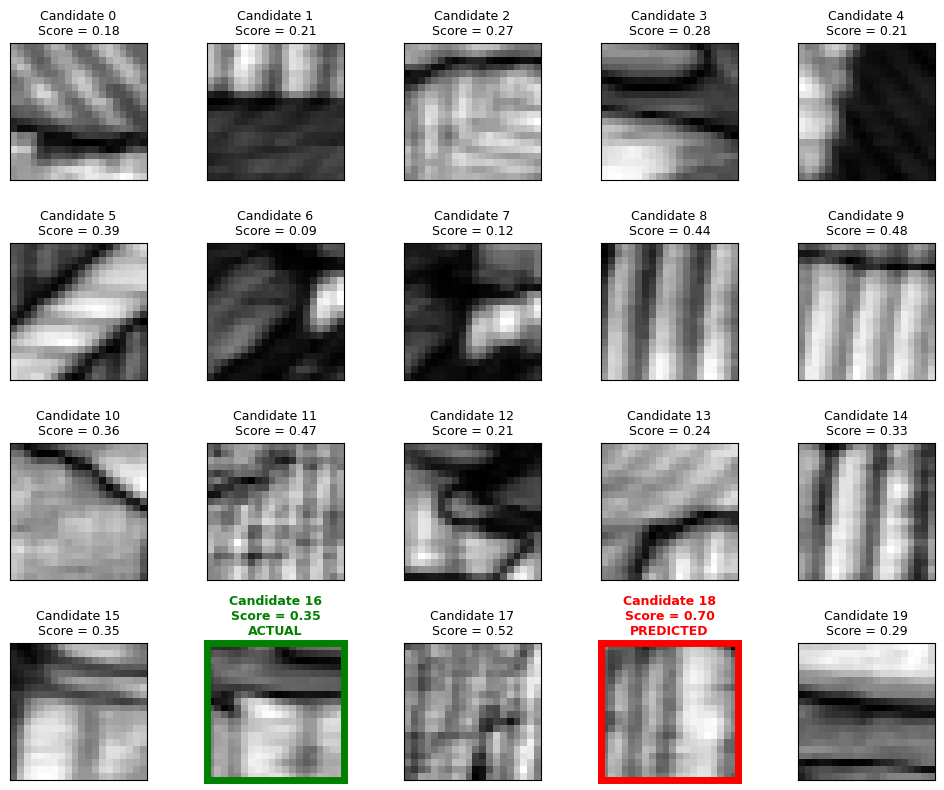

In [30]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(10, 8)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        patches[i],
        cmap="gray"
    )

    ax.set_title(
        f"Candidate {i}\nScore = {scores[i]:.2f}",
        fontsize=9
    )

    # --------------------------------------------------------
    # Highlight selections
    # --------------------------------------------------------

    if i == actual_selected and i == predicted_selected:

        for spine in ax.spines.values():
            spine.set_edgecolor("blue")
            spine.set_linewidth(5)

        ax.set_title(
            f"Candidate {i}\n"
            f"Score = {scores[i]:.2f}\n"
            f"ACTUAL + PREDICTED",
            fontsize=9,
            color="blue",
            weight="bold"
        )

    elif i == actual_selected:

        for spine in ax.spines.values():
            spine.set_edgecolor("green")
            spine.set_linewidth(5)

        ax.set_title(
            f"Candidate {i}\n"
            f"Score = {scores[i]:.2f}\n"
            f"ACTUAL",
            fontsize=9,
            color="green",
            weight="bold"
        )

    elif i == predicted_selected:

        for spine in ax.spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(5)

        ax.set_title(
            f"Candidate {i}\n"
            f"Score = {scores[i]:.2f}\n"
            f"PREDICTED",
            fontsize=9,
            color="red",
            weight="bold"
        )

    ax.set_xticks([])
    ax.set_yticks([])


plt.tight_layout()
plt.show()

### BENCHMARK HYPOTHESIZED REWARD ACROSS ALL STEPS

In [31]:
results = []

for step in sorted(trace.keys()):

    step_data = trace[step]

    patches = step_data["patches"]
    actual_selected = step_data["selected_candidate"]

    # Score all candidates in this step
    scores = np.array([
        reward(patch)
        for patch in patches
    ])

    # Predicted choice = highest score
    predicted_selected = int(
        np.argmax(scores)
    )

    results.append({
        "step": step + 1,
        "actual": actual_selected,
        "predicted": predicted_selected,
        "correct": int(
            predicted_selected == actual_selected
        )
    })


results = pd.DataFrame(results)

accuracy = results["correct"].mean()

print(f"Trace {TRACE_ID}")
print(f"Accuracy: {accuracy:.1%}")
print(f"Correct: {results['correct'].sum()} / {len(results)}")
print(f"Random baseline: {1 / len(trace[0]['patches']):.1%}")

results

Trace 6
Accuracy: 1.0%
Correct: 1 / 100
Random baseline: 5.0%


,step,actual,predicted,correct
0,1,16,18,0
1,2,2,10,0
2,3,12,6,0
3,4,6,12,0
4,5,8,0,0
...,...,...,...,...
95,96,5,19,0
96,97,1,2,0
97,98,3,12,0
98,99,5,11,0
